# CLUSTERING

Este notebook aborda la **Tarea 2 del proyecto DSMarket**: la segmentación no supervisada del catálogo de productos mediante KMeans. El objetivo es transformar 3.049 productos individuales en grupos de comportamiento accionables que permitan diseñar estrategias comerciales diferenciadas por segmento.

## 📋 Índice

1. [Importación de librerías](#1-importación-de-librerias)
2. [Importación de datos](#2-importacion-de-datos)
   - [2.1 Ventas](#21-ventas)
   - [2.2 Calendario](#22-calendario)
   - [2.3 Precios](#23-precios)
3. [Gestión y unión de tablas](#3-gestión-de-tablas-para-poder-unirlas-en-1-solo-dataset)
   - [3.1 Calendario](#31-calendar)
   - [3.2 Ventas](#32-ventas)
   - [3.3 Unión](#33-unión-de-ventas)
4. [Feature Engineering](#4-feature-engineering)
   - [4.2 Pipeline de preprocesamiento](#42-pipeline-de-preprocesamiento)
   - [4.3 Optimización de memoria](#43-optimización-de-memoria)
5. [Agregación y construcción de features](#5-agregación-y-construcción-de-features)
6. [Modelo de Clustering](#6-modelo-de-clustering--kmeans)
   - [6.1 Selección del número óptimo de k](#61-selección-del-número-óptimo-de-clusters-k)
   - [6.2 Selección de k=6](#62-selección-de-k--6)
7. [Análisis de resultados](#7-análisis-de-resultados)
   - [7.1 Ficha descriptiva por cluster](#71-ficha-descriptiva-por-cluster)
   - [7.2 Visualización PCA 2D](#72-visualización-pca-2d)
8. [Exportación para Power BI](#8-exportación-para-power-bi)

## 1. Importación de librerias

In [ ]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import sklearn
from sklearn import set_config

set_config(transform_output="pandas")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from narwhals import corr
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import plotly.express as px




In [ ]:
print("Working with this sklearn version {}".format(sklearn.__version__))

Working with this sklearn version 1.6.1


In [ ]:
sales_data_path = r"data\item_sales.csv"
calendar_data_path = r"data\daily_calendar_with_events.csv"
prices_data_path = r"data\item_prices.csv"

## 2. Importacion de datos

El dataset de DSMarket se construye a partir de tres fuentes independientes que deben unirse antes de poder trabajar con ellas:

| Fichero | Contenido | Granularidad |
|---|---|---|
| `item_sales.csv` | Unidades vendidas por producto y tienda | Diaria (una columna por día) |
| `daily_calendar_with_events.csv` | Fechas, días de la semana y eventos | Diaria |
| `item_prices.csv` | Precio de venta por producto, tienda y semana | Semanal |

El proceso de unión requiere transformar el dataset de ventas de formato **wide** (una columna por día) a formato **long** (una fila por día) para poder hacer el merge con el calendario y los precios.

### 2.1 Ventas

El df de ventas tiene los datos de ventas por día, organizado de forma que cada día tiene su columna. Vamos a tener que hacer una transformación para que los días formen parte de una sola columna, para poder agruparlos por semanas y que el 'pd_sales' se pueda unir con las demás tablas.  

In [ ]:
pd_sales = pd.read_csv(sales_data_path, sep = ",")
print("La forma del dataframe de ventas es:", pd_sales.shape)

La forma del dataframe de ventas es: (30490, 1920)


In [ ]:
pd_sales.head()

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [ ]:
pd_sales.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Data columns (total 1920 columns):
 #     Column      Dtype 
---    ------      ----- 
 0     id          object
 1     item        object
 2     category    object
 3     department  object
 4     store       object
 5     store_code  object
 6     region      object
 7     d_1         int64 
 8     d_2         int64 
 9     d_3         int64 
 10    d_4         int64 
 11    d_5         int64 
 12    d_6         int64 
 13    d_7         int64 
 14    d_8         int64 
 15    d_9         int64 
 16    d_10        int64 
 17    d_11        int64 
 18    d_12        int64 
 19    d_13        int64 
 20    d_14        int64 
 21    d_15        int64 
 22    d_16        int64 
 23    d_17        int64 
 24    d_18        int64 
 25    d_19        int64 
 26    d_20        int64 
 27    d_21        int64 
 28    d_22        int64 
 29    d_23        int64 
 30    d_24        int64 
 31    d_25        int64 
 32  

### 2.2 Calendario

'pd_calendar' tiene un día por fila y una columna 'event' que indica si hay evento (indica nombre) o no (valor nulo). Deberemos añadir una columna que indique la semana del año para poder unirla a las demás tablas.

In [ ]:
pd_calendar = pd.read_csv(calendar_data_path, sep = ",")
print("La forma del dataframe de calendario es:", pd_calendar.shape)

La forma del dataframe de calendario es: (1913, 5)


In [ ]:
pd_calendar.head()

,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN
3,2011-02-01,Tuesday,4,d_4,NaN
4,2011-02-02,Wednesday,5,d_5,NaN


In [ ]:
pd_calendar.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         1913 non-null   object
 1   weekday      1913 non-null   object
 2   weekday_int  1913 non-null   int64 
 3   d            1913 non-null   object
 4   event        26 non-null     object
dtypes: int64(1), object(4)
memory usage: 74.9+ KB


### 2.3 Precios

- Esta tabla sí que está organizada de manera semanal. Como se puede apreciar hay varios valores por item, por lo que el precio puede variar por tienda y durante el tiempo.
- Tiene valores nulos en la columna 'yearweek', por lo que los precios no se podrían localizar en el tiempo. Se decide eliminar estos registros, pero si hubiese más input de datos con el mismo problema, habría que ver qué causa el valor nulo.

In [ ]:
pd_prices = pd.read_csv(prices_data_path, sep = ",")
print("La forma del dataframe de precios es:", pd_prices.shape)

La forma del dataframe de precios es: (6965706, 5)


In [ ]:
pd_prices.head()

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,201328.0,12.7414
1,ACCESORIES_1_001,ACCESORIES,NYC_1,201329.0,12.7414
2,ACCESORIES_1_001,ACCESORIES,NYC_1,201330.0,10.9858
3,ACCESORIES_1_001,ACCESORIES,NYC_1,201331.0,10.9858
4,ACCESORIES_1_001,ACCESORIES,NYC_1,201332.0,10.9858


In [ ]:
pd_prices.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965706 entries, 0 to 6965705
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    float64
 4   sell_price  float64
dtypes: float64(2), object(3)
memory usage: 265.7+ MB


In [ ]:
print("Hay {} items en el data, y el número de registros por item es: ".format(pd_prices.item.nunique()))
pd_prices.item.value_counts()

Hay 3049 items en el data, y el número de registros por item es: 


item
HOME_&_GARDEN_2_142    2870
HOME_&_GARDEN_2_193    2870
ACCESORIES_1_038       2870
HOME_&_GARDEN_2_184    2870
ACCESORIES_1_067       2870
                       ... 
HOME_&_GARDEN_1_308     652
HOME_&_GARDEN_1_159     633
HOME_&_GARDEN_1_242     610
SUPERMARKET_3_296       602
SUPERMARKET_2_379       543
Name: count, Length: 3049, dtype: int64

In [ ]:
pd_prices.describe()

,yearweek,sell_price
count,6.721786e+06,6.965706e+06
mean,2.013824e+05,5.518273e+00
std,1.450189e+02,4.387861e+00
min,2.011050e+05,1.200000e-02
25%,2.012480e+05,2.620100e+00
50%,2.014100e+05,4.200000e+00
75%,2.015150e+05,7.176000e+00
max,2.016170e+05,1.341500e+02


In [ ]:
pd_prices.describe(include=['object'])

,item,category,store_code
count,6965706,6965706,6965706
unique,3049,3,10
top,HOME_&_GARDEN_2_142,SUPERMARKET,BOS_2
freq,2870,3239821,713960


In [ ]:
pd_prices.yearweek.isnull().sum()/pd_prices.shape[0]

np.float64(0.03501726888846586)

In [ ]:
pd_prices.loc[pd_prices['yearweek'].isnull()]

,item,category,store_code,yearweek,sell_price
149,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.1454
150,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.1454
151,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.1454
152,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.1454
153,ACCESORIES_1_001,ACCESORIES,NYC_1,NaN,11.1454
...,...,...,...,...,...
6965701,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.2000
6965702,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.2000
6965703,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.2000
6965704,SUPERMARKET_3_827,SUPERMARKET,PHI_3,NaN,1.2000


In [ ]:
pd_prices = pd_prices.dropna(subset=['yearweek'])
pd_prices['yearweek'] = pd_prices['yearweek'].astype(int)

In [ ]:
pd_prices.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 6721786 entries, 0 to 6965697
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   item        object 
 1   category    object 
 2   store_code  object 
 3   yearweek    int64  
 4   sell_price  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 307.7+ MB


In [ ]:
df = pd.read_parquet(r"C:\Users\jorge\Documents\Nuclio - Data Scientist & Ia\TFM\DSMarket\clustering no supervisado\dsMarket.parquet")

In [ ]:
pd_prices['sell_price'].isnull().sum()/pd_prices.shape[0]

np.float64(0.0)

In [ ]:
pd_prices.reset_index(drop=True, inplace=True)

In [ ]:
pd_prices_sorted = pd_prices.sort_values(by=['item', 'store_code','yearweek']).reset_index(drop=True)

## 3. Gestión de tablas para poder unirlas en 1 solo dataset

Para poder construir el dataset final necesitamos resolver tres problemas:

1. **Calendario** — Añadir la columna `yearweek` para poder hacer el join con precios, y crear la variable `is_Ramadan` que marca los 30 días posteriores al inicio del Ramadán.
2. **Ventas** — Transformar de formato wide (una columna por día `d_1, d_2, ...`) a formato long (una fila por día), imprescindible para el merge.
3. **Unión** — Hacer el merge de las tres tablas usando `day` para unir ventas con calendario, e `item + store_code + yearweek` para unir con precios.

### 3.1. Calendar

Primero se crea la columna 'yearweek' para poder juntarla con las demás tablas. El día 1 de la semana corresponde al sábado y el 7 al viernes.

In [ ]:
from datetime import datetime, timedelta
def weekyearnum(dt):
    return dt.strftime("%Y%W")

def myweekyearnum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weekyearnum(offsetdt)

def weeknum(dt):
    return dt.isocalendar()[1]

def myweeknum(dt):
    offsetdt = dt + timedelta(days=+2);  # you add 3 days to Mon to get to Thu
    return weeknum(offsetdt)

In [ ]:
## Merge
pd_calendar['date'] = pd.to_datetime(pd_calendar['date'], format = "%Y-%m-%d")

pd_calendar['yearweek'] = pd_calendar['date'].apply(lambda x: myweekyearnum(x)).astype(int)

#### Adición de la columna 'is_Ramadan'

In [ ]:
pd_calendar.loc[pd_calendar['event']=="Ramadan starts"]

,date,weekday,weekday_int,d,event,yearweek
184,2011-08-01,Monday,3,d_185,Ramadan starts,201131
538,2012-07-20,Friday,7,d_539,Ramadan starts,201229
892,2013-07-09,Tuesday,4,d_893,Ramadan starts,201327
1247,2014-06-29,Sunday,2,d_1248,Ramadan starts,201426
1601,2015-06-18,Thursday,6,d_1602,Ramadan starts,201524


In [ ]:
pd_calendar['is_Ramadan'] = 0

ramadan_starts = pd_calendar.loc[pd_calendar['event'] == 'Ramadan starts', 'date']

for start_date in ramadan_starts:
    mask = (pd_calendar['date'] >= start_date) & (pd_calendar['date'] < start_date + pd.Timedelta(days=30))
    
    pd_calendar.loc[
        mask,
        'is_Ramadan'
    ] = 1

In [ ]:
pd_calendar.rename(columns={'d': 'day'}, inplace=True)

In [ ]:
pd_calendar['is_Event'] = pd_calendar['event'].notnull()

### 3.2 Ventas

Se deben pasar los días de columnas a una columna

In [ ]:
pd_sales.set_index(['id','item','category','department','store','store_code','region']).head()

,,,,,,,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
id,item,category,department,store,store_code,region,,,,,,,,,,,,,,,,,,,,,
ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [ ]:
for c in pd_sales.columns:
    if pd_sales[c].dtype == 'object':
        pd_sales[c] = pd_sales[c].astype('category')

In [ ]:
pd_sales_long = pd_sales.melt(
    id_vars=['id','item','category','department','store','store_code','region'],
    var_name='day',
    value_name='sales'
)

In [ ]:
pd_sales_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 9 columns):
 #   Column      Dtype   
---  ------      -----   
 0   id          category
 1   item        category
 2   category    category
 3   department  category
 4   store       category
 5   store_code  category
 6   region      category
 7   day         object  
 8   sales       int64   
dtypes: category(7), int64(1), object(1)
memory usage: 1.4+ GB


In [ ]:
pd_sales_long.loc[pd_sales_long['id'] == 'ACCESORIES_1_005_NYC_1']

,id,item,category,department,store,store_code,region,day,sales
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
30494,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_2,0
60984,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_3,0
91474,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_4,0
121964,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_5,0
...,...,...,...,...,...,...,...,...,...
58174924,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1909,1
58205414,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1910,2
58235904,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1911,2
58266394,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1912,2


In [ ]:
pd_sales_long.head()

,id,item,category,department,store,store_code,region,day,sales
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
3,ACCESORIES_1_004_NYC_1,ACCESORIES_1_004,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0
4,ACCESORIES_1_005_NYC_1,ACCESORIES_1_005,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0


In [ ]:
pd_sales.head(1)

,id,item,category,department,store,store_code,region,d_1,d_2,d_3,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,...,1,3,0,1,1,1,3,0,1,1


## 3.3 unión de ventas

In [ ]:
df_dsMarket = pd_sales_long.merge(
    pd_calendar[['day', 'yearweek', 'event', 'is_Ramadan', 'is_Event', 'date']],
    on='day',
    how='left'
)

In [ ]:
pd_prices.head(1)

,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,201328,12.7414


In [ ]:
df_dsMarket = df_dsMarket.merge(
    pd_prices[['item', 'store_code', 'yearweek', 'sell_price']],
    on=['item', 'store_code', 'yearweek'],
    how='inner'
)

In [ ]:
# Cálculo de ingresos
df_dsMarket['revenue'] = df_dsMarket['sales']*df_dsMarket['sell_price']

In [ ]:
df_dsMarket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46027957 entries, 0 to 46027956
Data columns (total 16 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   yearweek    int64         
 10  event       object        
 11  is_Ramadan  int64         
 12  is_Event    bool          
 13  date        datetime64[ns]
 14  sell_price  float64       
 15  revenue     float64       
dtypes: bool(1), category(5), datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 3.7+ GB


In [ ]:
df_dsMarket['store_id'] = df_dsMarket['store_code'].astype(str) + '_' + df_dsMarket['department'].astype(str)

In [ ]:
df_dsMarket.isnull().sum()

id                   0
item                 0
category             0
department           0
store                0
store_code           0
region               0
day                  0
sales                0
yearweek             0
event         45391927
is_Ramadan           0
is_Event             0
date                 0
sell_price           0
revenue              0
store_id             0
dtype: int64

In [ ]:
df_dsMarket['yearweek'].max()

np.int64(201617)

In [ ]:
df_dsMarket = df_dsMarket.loc[df_dsMarket['yearweek'] < df_dsMarket['yearweek'].max()]

In [ ]:
df_dsMarket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45966977 entries, 0 to 45966976
Data columns (total 17 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   yearweek    int64         
 10  event       object        
 11  is_Ramadan  int64         
 12  is_Event    bool          
 13  date        datetime64[ns]
 14  sell_price  float64       
 15  revenue     float64       
 16  store_id    object        
dtypes: bool(1), category(5), datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 4.4+ GB


In [ ]:
df = df_dsMarket.copy()

## 4. Feature Engineering

Una vez construido el dataset integrado, aplicamos ingeniería de features para enriquecer cada fila con variables de comportamiento que el modelo de clustering pueda utilizar.

Este proceso se implementa mediante **transformadores custom** integrados en un pipeline de sklearn, lo que garantiza reproducibilidad, evita fugas de información entre pasos y permite reutilizar el mismo pipeline en producción.

### Transformadores implementados

| Transformador | Función | Estado |
|---|---|---|
| `SeasonExtractor` | Asigna la estación astronómica (Winter/Spring/Summer/Autumn) a cada fecha | ✅ Activo |
| `DiscountTransformer` | Detecta descuentos reales con ventana deslizante de 28 días, corrigiendo lookahead bias. Calcula también la profundidad del descuento | ✅ Activo |
| `EventTransformer` | Identifica eventos globales y locales por región (maratones, St. Patrick's...) | ❌ Sin señal discriminante |
| `PaydayTransformer` | Marca días de pago (1, 2, 15 y 16 de cada mes) | ❌ Sin señal discriminante |
| `EventLeadUpTransformer` | Marca los 3 días previos a cualquier evento | ❌ Sin señal discriminante |

> **Nota metodológica:** Los transformadores desactivados fueron evaluados e incluidos en el barrido de Silhouette Score. Su inclusión empeoraba el score en todas las k testadas, lo que indica que no aportan señal discriminante para este catálogo de productos. Esto es en sí mismo un resultado válido — los eventos y días de pago afectan a todos los productos por igual, sin diferenciar comportamientos entre segmentos.

In [ ]:
df.head()

,id,item,category,department,store,store_code,region,day,sales,yearweek,event,is_Ramadan,is_Event,date,sell_price,revenue,store_id
0,ACCESORIES_1_008_NYC_1,ACCESORIES_1_008,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,12,201105,NaN,0,False,2011-01-29,0.6118,7.3416,NYC_1_ACCESORIES_1
1,ACCESORIES_1_009_NYC_1,ACCESORIES_1_009,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,2,201105,NaN,0,False,2011-01-29,2.0748,4.1496,NYC_1_ACCESORIES_1
2,ACCESORIES_1_010_NYC_1,ACCESORIES_1_010,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,201105,NaN,0,False,2011-01-29,4.2161,0.0000,NYC_1_ACCESORIES_1
3,ACCESORIES_1_012_NYC_1,ACCESORIES_1_012,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,0,201105,NaN,0,False,2011-01-29,7.9534,0.0000,NYC_1_ACCESORIES_1
4,ACCESORIES_1_015_NYC_1,ACCESORIES_1_015,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,d_1,4,201105,NaN,0,False,2011-01-29,0.9310,3.7240,NYC_1_ACCESORIES_1


In [ ]:
df["event"].value_counts    ()

event
SuperBowl         138440
Easter            130145
NewYear           124653
Thanksgiving      123642
Ramadan starts    119150
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45966977 entries, 0 to 45966976
Data columns (total 17 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   yearweek    int64         
 10  event       object        
 11  is_Ramadan  int64         
 12  is_Event    bool          
 13  date        datetime64[ns]
 14  sell_price  float64       
 15  revenue     float64       
 16  store_id    object        
dtypes: bool(1), category(5), datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 4.4+ GB


In [ ]:

# 1. TRANSFORMADOR DE ESTACIONES (Exactitud astronómica)
class SeasonExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, date_column='date'):
        self.date_column = date_column
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_out = X.copy()
        fechas = pd.to_datetime(X_out[self.date_column])
        mmdd = fechas.dt.month * 100 + fechas.dt.day
        
        # Definición de cortes para las estaciones
        bins = [0, 319, 620, 921, 1220, 1300]
        labels = ['Winter', 'Spring', 'Summer', 'Autumn', 'Winter_end']
        
        X_out['season'] = pd.cut(mmdd, bins=bins, labels=labels).replace('Winter_end', 'Winter')
        return X_out

# 2. TRANSFORMADOR DE EVENTOS (Globales + Locales + Maratones)
class EventTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_col='date', region_col='region', event_col='event'):
        self.date_col = date_col
        self.region_col = region_col
        self.event_col = event_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        fechas = pd.to_datetime(X_out[self.date_col])
        mes = fechas.dt.month
        dia = fechas.dt.day
        dia_semana = fechas.dt.dayofweek # 0=Lunes, 6=Domingo
        
        # Inicializamos la columna de eventos locales
        X_out['local_event_name'] = 'NoEvent'
        
        # --- LÓGICA DE EVENTOS LOCALES ---
        
        # Boston: Patriots' Day & Marathon (3er lunes de Abril: días entre 15-21 y que sea lunes)
        mask_boston = (X_out[self.region_col] == 'Boston') & (mes == 4) & (dia.between(15, 21)) & (dia_semana == 0)
        X_out.loc[mask_boston, 'local_event_name'] = 'Boston_Marathon_Patriots_Day'
        
        # NY: Marathon (1er domingo de Noviembre: días entre 1-7 y que sea domingo)
        mask_ny_marathon = (X_out[self.region_col] == 'New York') & (mes == 11) & (dia.between(1, 7)) & (dia_semana == 6)
        X_out.loc[mask_ny_marathon, 'local_event_name'] = 'NY_Marathon'

        # Philly: Broad Street Run (1er domingo de Mayo)
        mask_philly_run = (X_out[self.region_col] == 'Philadelphia') & (mes == 5) & (dia.between(1, 7)) & (dia_semana == 6)
        X_out.loc[mask_philly_run, 'local_event_name'] = 'Broad_Street_Run'

        # NY: St. Patrick's Day (17 de Marzo)
        mask_ny_stpat = (X_out[self.region_col] == 'New York') & (mes == 3) & (dia == 17)
        X_out.loc[mask_ny_stpat, 'local_event_name'] = 'St_Patricks_Day'

        # Philly: Mummers Parade (1 de Enero)
        mask_philly_mummers = (X_out[self.region_col] == 'Philadelphia') & (mes == 1) & (dia == 1)
        X_out.loc[mask_philly_mummers, 'local_event_name'] = 'Mummers_Parade'

        # --- CONSOLIDACIÓN ---
        
        # Creamos 'final_event': prioriza el evento global, si no hay, pone el local.
        X_out['final_event'] = np.where(X_out[self.event_col] != 'NoEvent', 
                                        X_out[self.event_col], 
                                        X_out['local_event_name'])
        
        # Variable binaria útil para clustering (¿Hay algún evento hoy?)
        X_out['is_event_day'] = (X_out['final_event'] != 'NoEvent').astype(int)

        # Limpiamos columnas auxiliares
        X_out = X_out.drop(columns=['local_event_name'])
        
        return X_out
# 3. TRANSFORMADOR DE DÍAS DE PAGO (Payday)
class PaydayTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_col='date'):
        self.date_col = date_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        dias = pd.to_datetime(X_out[self.date_col]).dt.day
        
        # En EE.UU. se suele cobrar el 1 y el 15. 
        # Añadimos el 2 y el 16 para capturar el pico de consumo inmediato y posibles retrasos por fin de semana.
        X_out['is_payday'] = dias.isin([1, 2, 15, 16]).astype(int)
        
        return X_out
# 4. TRANSFORMADOR DE DESCUENTOS REALES     
class DiscountTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, id_col='item', date_col='date', price_col='sell_price', 
                 window_days=28, threshold=0.05):
        self.id_col = id_col
        self.date_col = date_col
        self.price_col = price_col
        self.window_days = window_days
        self.threshold = threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        eps = 1e-8
        
        X_out = X_out.sort_values([self.id_col, self.date_col])
        
        precio_referencia = X_out.groupby(self.id_col)[self.price_col].transform(
            lambda x: x.shift(1).rolling(window=self.window_days, min_periods=1).max()
        )
        
        # Fallback: si no hay historial (primeros días), usar el precio actual
        precio_referencia = precio_referencia.fillna(X_out[self.price_col])
        
        limite_oferta = precio_referencia * (1 - self.threshold)
        
        X_out['is_discounted'] = (X_out[self.price_col] < limite_oferta).astype(int)
        X_out['discount_depth'] = np.where(
            X_out['is_discounted'] == 1,
            (precio_referencia - X_out[self.price_col]) / (precio_referencia + eps),
            0.0
        )
        
        X_out = X_out.sort_index()
        return X_out

# 5. TRANSFORMADOR DE DÍAS DE PREVIOS A EVENTO
class EventLeadUpTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, store_col='store_id', date_col='date', event_col='is_event_day', lead_days=3):
        # lead_days=3 significa que marcaremos como "víspera" los 3 días anteriores a cualquier evento
        self.store_col = store_col
        self.date_col = date_col
        self.event_col = event_col
        self.lead_days = lead_days

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        
        # 1. Ordenamos por tienda y fecha (Vital para no mezclar eventos del futuro de otra tienda)
        X_out = X_out.sort_values([self.store_col, self.date_col])
        
        # Array inicial de ceros
        lead_up_series = np.zeros(len(X_out), dtype=int)
        
        # 2. Miramos hacia el futuro 'lead_days' días
        # Si hoy es lunes y el evento es el jueves (3 días), marcamos lunes, martes y miércoles.
        for i in range(1, self.lead_days + 1):
            # shift(-i) "sube" las filas, trayendo el futuro al presente.
            # fillna(0) evita errores en los últimos días del dataset.
            shifted = X_out.groupby(self.store_col)[self.event_col].shift(-i).fillna(0).astype(int)
            
            # Usamos el operador lógico OR (|) para combinar todos los días previos
            lead_up_series = lead_up_series | shifted
            
        # 3. Asignamos la nueva variable y restauramos el orden original
        X_out['is_event_leadup'] = lead_up_series
        X_out = X_out.sort_index()
        
        return X_out

### 4.2 Pipeline de preprocesamiento

El pipeline encadena los transformadores activos en el orden correcto. El `DiscountTransformer` debe ejecutarse **después** del `SeasonExtractor` y **antes** del `ProductProfiler` porque genera las variables `is_discounted` y `discount_depth` que el profiler necesita.


In [ ]:

feature_engineering_pipeline = Pipeline([
    ('season_extractor', SeasonExtractor(date_column='date')),
    #('events', EventTransformer(region_col='region', event_col='event')),
    #("payday", PaydayTransformer(date_col='date')),
    ('discounts', DiscountTransformer(id_col='id', date_col='date', price_col='sell_price')),
    #('event_leadup', EventLeadUpTransformer(store_col='store_id', date_col='date', event_col='is_event_day'))
])


In [ ]:
df2 = df.copy()

### 4.3 Optimización de memoria

El dataset integrado ocupa una cantidad significativa de RAM en sus tipos de dato por defecto (`int64`, `float64`). Antes de ejecutar el pipeline aplicamos un proceso de **downcasting** que reduce el consumo de memoria entre un 40% y un 60% sin pérdida de información relevante para el clustering:

- `object` → `category` para columnas categóricas
- `int64` → `int32` para columnas enteras (soporta hasta 2.147 millones)
- `float64` → `float32` para columnas decimales

In [ ]:
# 1. Eliminamos columnas redundantes o inútiles para el clustering
columnas_sobrantes = ['day', 'store', 'store_code', 'yearweek']
df_opt = df2.drop(columns=[col for col in columnas_sobrantes if col in df2.columns])

# 2. Conversión de Objects a Categorías
columnas_categoricas = ['item', 'event', 'store_id']
for col in columnas_categoricas:
    if col in df_opt.columns:
        df_opt[col] = df_opt[col].astype('category')

# 3. Downcasting de números enteros (de 64 a 32 bits)
columnas_enteras = df_opt.select_dtypes(include=['int64']).columns
for col in columnas_enteras:
    df_opt[col] = df_opt[col].astype('int32')

# 4. Downcasting de decimales (de 64 a 32 bits)
columnas_float = df_opt.select_dtypes(include=['float64']).columns
for col in columnas_float:
    df_opt[col] = df_opt[col].astype('float32')

# Imprimimos el resultado de la dieta
print("--- ANTES ---")
df2.info(memory_usage='deep')
print("\n--- DESPUÉS ---")
df_opt.info(memory_usage='deep')

--- ANTES ---
<class 'pandas.core.frame.DataFrame'>
Index: 45966977 entries, 0 to 45966976
Data columns (total 17 columns):
 #   Column      Dtype         
---  ------      -----         
 0   id          category      
 1   item        object        
 2   category    category      
 3   department  category      
 4   store       category      
 5   store_code  object        
 6   region      category      
 7   day         object        
 8   sales       int64         
 9   yearweek    int64         
 10  event       object        
 11  is_Ramadan  int64         
 12  is_Event    bool          
 13  date        datetime64[ns]
 14  sell_price  float64       
 15  revenue     float64       
 16  store_id    object        
dtypes: bool(1), category(5), datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 14.5 GB

--- DESPUÉS ---
<class 'pandas.core.frame.DataFrame'>
Index: 45966977 entries, 0 to 45966976
Data columns (total 13 columns):
 #   Column      Dtype         
---  -

In [ ]:


df_procesado = feature_engineering_pipeline.fit_transform(df_opt)

In [ ]:
df_procesado.head()

,id,item,category,department,region,sales,event,is_Ramadan,is_Event,date,sell_price,revenue,store_id,season,is_discounted,discount_depth
0,ACCESORIES_1_008_NYC_1,ACCESORIES_1_008,ACCESORIES,ACCESORIES_1,New York,12,NaN,0,False,2011-01-29,0.6118,7.3416,NYC_1_ACCESORIES_1,Winter,0,0.0
1,ACCESORIES_1_009_NYC_1,ACCESORIES_1_009,ACCESORIES,ACCESORIES_1,New York,2,NaN,0,False,2011-01-29,2.0748,4.1496,NYC_1_ACCESORIES_1,Winter,0,0.0
2,ACCESORIES_1_010_NYC_1,ACCESORIES_1_010,ACCESORIES,ACCESORIES_1,New York,0,NaN,0,False,2011-01-29,4.2161,0.0000,NYC_1_ACCESORIES_1,Winter,0,0.0
3,ACCESORIES_1_012_NYC_1,ACCESORIES_1_012,ACCESORIES,ACCESORIES_1,New York,0,NaN,0,False,2011-01-29,7.9534,0.0000,NYC_1_ACCESORIES_1,Winter,0,0.0
4,ACCESORIES_1_015_NYC_1,ACCESORIES_1_015,ACCESORIES,ACCESORIES_1,New York,4,NaN,0,False,2011-01-29,0.9310,3.7240,NYC_1_ACCESORIES_1,Winter,0,0.0


## 5. Agregación y construcción de features

Una vez preprocesado el dataset a nivel de fila diaria, lo agregamos a nivel de **producto** mediante el `ProductProfiler` — un transformador custom que calcula las **7 dimensiones de comportamiento** que alimentarán el modelo de clustering.

El `ProductProfiler` filtra primero la **vida activa** de cada producto (desde su primera venta real), evitando que los días de cero ventas previos al lanzamiento distorsionen las métricas.

### Las 7 dimensiones del modelo final

| # | Dimensión | Descripción | Transformación |
|---|---|---|---|
| 1 | `volumen_total` | Total de unidades vendidas en vida activa | log1p |
| 2 | `precio_medio` | Precio medio histórico | log1p |
| 3 | `frecuencia_venta` | Proporción de días con ventas > 0 | ratio |
| 4 | `volatilidad` | Coeficiente de variación de ventas diarias | log1p |
| 5 | `p_oferta` | Proporción de ventas en días de descuento | ratio |
| 6 | `profundidad_descuento` | Magnitud media del descuento cuando hay oferta | ratio |
| 7 | `p_primavera_verano` | Proporción de ventas en temporada cálida | ratio |

> **Nota sobre multicolinealidad estacional:** Se evaluaron las 4 estaciones por separado pero su suma siempre es 1.0 (multicolinealidad perfecta confirmada), por lo que se redujo a una única variable de estacionalidad.

> **Nota sobre transformaciones log1p:** Se aplica a volumen, precio y volatilidad para comprimir colas largas y distribuciones asimétricas, mejorando el comportamiento de KMeans al igualar la escala de variación entre variables.

El pipeline final añade un `RobustScaler` que normaliza las 7 dimensiones minimizando el impacto de outliers antes de pasarlas a KMeans.

In [ ]:

columnas_necesarias = [
    'date', 'item', 'sales', 'revenue', 'sell_price', 'region', 
    'store_id', 'discount_depth', 'is_discounted', 'season'
]

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns].copy()

class ProductProfiler(BaseEstimator, TransformerMixin):
    def __init__(self, groupby_col='item'):
        self.groupby_col = groupby_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        # Si 'date' ya es datetime por el paso de optimización, esto no hace daño
        X_out['date'] = pd.to_datetime(X_out['date']) 
        
        # Identificar inicio de vida del producto
        first_sales = X_out[X_out['sales'] > 0].groupby(self.groupby_col)['date'].min().reset_index()
        first_sales.columns = [self.groupby_col, 'first_sale_date']
        X_out = X_out.merge(first_sales, on=self.groupby_col, how='left')
        
        # Filtrar vida activa
        X_active = X_out[X_out['date'] >= X_out['first_sale_date']].copy()
        
        
        X_active['sales_discount'] = X_active['sales'] * X_active['is_discounted']
               
        seasons = pd.get_dummies(X_active['season'], prefix='sales')
        for col in seasons.columns:
            X_active[col] = X_active['sales'] * seasons[col]
             
        X_active['sales_spring_summer'] = X_active['sales_Spring'] + X_active['sales_Summer']

        
        grouped = X_active.groupby(self.groupby_col).agg(
            total_sales=('sales', 'sum'),
            avg_sales_daily=('sales', 'mean'),
            std_sales=('sales', 'std'),        
            avg_price=('sell_price', 'mean'),
            max_price=('sell_price', 'max'),   
            min_price=('sell_price', 'min'),   
            real_life_days=('date', 'count'), 
            days_with_sales=('sales', lambda x: (x > 0).sum()),
            sum_s_discount=('sales_discount', 'sum'),
            avg_discount_depth=('discount_depth', lambda x: x[x > 0].mean()),
            #sum_s_winter=('sales_Winter', 'sum'),
            sum_s_spring_summer=('sales_spring_summer', 'sum'),
            
        )

        eps = 1e-8

        
        # 👉 4. Cálculo de métricas finales
        res = pd.DataFrame(index=grouped.index)
        res['volumen_total'] = np.log1p(grouped['total_sales']) 
        res['precio_medio'] = np.log1p(grouped['avg_price'])
        res['frecuencia_venta'] = grouped['days_with_sales'] / (grouped['real_life_days'] + eps)
        res['volatilidad'] = np.log1p(grouped['std_sales'] / (grouped['avg_sales_daily'] + eps))
        # Ratios de comportamiento
        sales = grouped['total_sales'] + eps
        res['p_oferta'] = grouped['sum_s_discount'] / sales
        res['profundidad_descuento'] =grouped['avg_discount_depth']
        
        res['p_primavera_verano'] = grouped['sum_s_spring_summer'] / sales
              
        return res.fillna(0)

In [ ]:
cluster_pipeline = Pipeline([
    ("Selector", ColumnSelector(columns=columnas_necesarias)),
    ("profiler", ProductProfiler(groupby_col = "item")),
    ("RobustScaler", RobustScaler()),

])

In [ ]:
cluster_pipeline

Pipeline(steps=[('Selector',
                 ColumnSelector(columns=['date', 'item', 'sales', 'revenue',
                                         'sell_price', 'region', 'store_id',
                                         'discount_depth', 'is_discounted',
                                         'season'])),
                ('profiler', ProductProfiler()),
                ('RobustScaler', RobustScaler())])

In [ ]:
df_agg = cluster_pipeline.fit_transform(df_procesado)

In [ ]:
df_agg

,volumen_total,precio_medio,frecuencia_venta,volatilidad,p_oferta,profundidad_descuento,p_primavera_verano
item,,,,,,,
ACCESORIES_1_001,-0.528171,1.033096,-0.255335,0.106271,0.402062,0.067957,-0.953879
ACCESORIES_1_002,-0.394355,0.234388,-0.497888,0.504346,-0.110837,1.803374,-0.828144
ACCESORIES_1_003,-1.180342,-0.058598,-0.701138,0.922247,0.403209,2.756579,-0.100532
ACCESORIES_1_004,0.880046,0.365263,0.805904,-0.582105,-0.134217,-0.845159,-0.026409
ACCESORIES_1_005,0.265928,-0.086267,0.188149,-0.253530,2.119831,-0.073907,-0.749695
...,...,...,...,...,...,...,...
SUPERMARKET_3_823,0.298514,-0.216680,-0.149741,0.375287,4.635525,-0.095582,-0.757504
SUPERMARKET_3_824,-0.083826,-0.310433,-0.335347,0.484043,0.824015,-0.090048,1.487034
SUPERMARKET_3_825,0.217728,0.165591,0.036992,-0.051365,2.633626,-0.149822,0.238923


## 6. Modelo de Clustering — KMeans

Con las 7 features construidas y escaladas, aplicamos **KMeans** para identificar los grupos naturales del catálogo de 3.049 productos.

KMeans agrupa los productos minimizando la distancia euclidiana de cada producto a su centroide. Al ser no supervisado, no necesita etiquetas previas — los grupos emergen directamente de la estructura de los datos.



### 6.1 Selección del número óptimo de clusters (k)

Se evalúan dos métricas complementarias para elegir k de forma rigurosa:

- **Método del codo (Elbow):** Representa la inercia (SSE) en función de k. Se busca el punto donde la reducción de SSE se vuelve marginal — el "codo" de la curva.
- **Silhouette Score:** Mide simultáneamente la cohesión interna de cada cluster y su separación respecto a los demás. Rango entre -1 y 1, donde valores más altos indican clusters más compactos y bien separados.

Ambas métricas se calculan para k entre 2 y 14.

### Elbow curve

In [ ]:
sse = {}

for k in range(2, 15):
    print(f"Fitting pipe with {k} clusters")
    clustering_model = KMeans(n_clusters=k, random_state=42)
    clustering_model.fit(df_agg)
    sse[k] = clustering_model.inertia_

Fitting pipe with 2 clusters
Fitting pipe with 3 clusters
Fitting pipe with 4 clusters
Fitting pipe with 5 clusters
Fitting pipe with 6 clusters
Fitting pipe with 7 clusters
Fitting pipe with 8 clusters
Fitting pipe with 9 clusters
Fitting pipe with 10 clusters
Fitting pipe with 11 clusters
Fitting pipe with 12 clusters
Fitting pipe with 13 clusters
Fitting pipe with 14 clusters


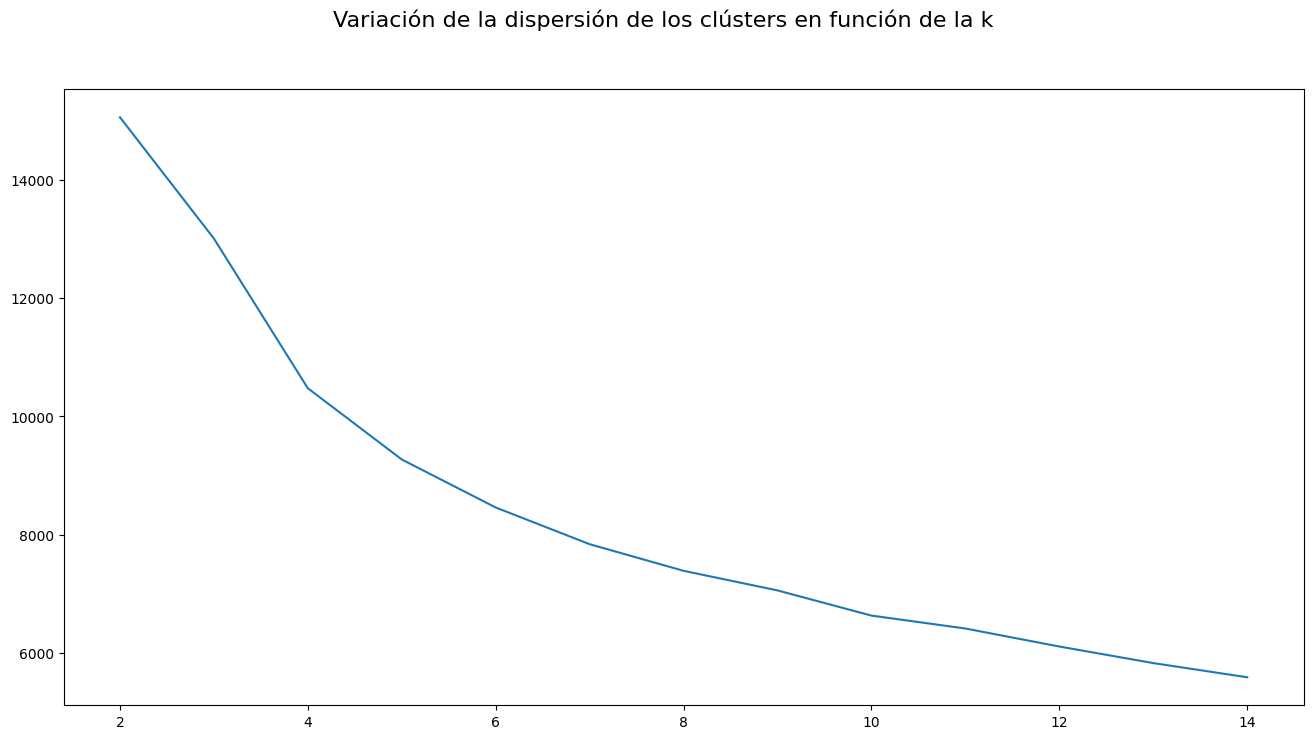

In [ ]:
fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot()

x_values = list(sse.keys())
y_values = list(sse.values())

ax.plot(x_values, y_values, label = "Inertia/dispersión de los clústers")
fig.suptitle(
    "Variación de la dispersión de los clústers en función de la k", fontsize = 16
);

In [ ]:
from sklearn.metrics import silhouette_score

silhouettes = {}
for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=42)
    labels_k = km.fit_predict(df_agg)
    silhouettes[k] = silhouette_score(df_agg, labels_k)

# Ver ambas métricas juntas
for k in silhouettes:
    print(f"k={k:2d} | Silhouette: {silhouettes[k]:.4f} | SSE: {sse[k]:.0f}")

k= 2 | Silhouette: 0.1878 | SSE: 15055
k= 3 | Silhouette: 0.1966 | SSE: 13005
k= 4 | Silhouette: 0.2218 | SSE: 10476
k= 5 | Silhouette: 0.2342 | SSE: 9273
k= 6 | Silhouette: 0.2247 | SSE: 8461
k= 7 | Silhouette: 0.2171 | SSE: 7841
k= 8 | Silhouette: 0.2050 | SSE: 7391
k= 9 | Silhouette: 0.1954 | SSE: 7060
k=10 | Silhouette: 0.1793 | SSE: 6635
k=11 | Silhouette: 0.1789 | SSE: 6416
k=12 | Silhouette: 0.1818 | SSE: 6112
k=13 | Silhouette: 0.1857 | SSE: 5832
k=14 | Silhouette: 0.1847 | SSE: 5592


### 6.2 Selección de k = 6

El análisis conjunto de ambas métricas apunta a **k = 6** como el número óptimo:

- El **Silhouette Score** alcanza su máximo en k = 5 (0,2342)
- El **método del codo** muestra una inflexión clara alrededor de k = 6, tras la cual la reducción de SSE se vuelve marginal

> **Nota sobre el Silhouette Score:** El valor 0,2345 es normal y esperable en datos de retail, donde los productos forman un espectro continuo de comportamientos en lugar de grupos perfectamente discretos. Como referencia, en la literatura de retail un Silhouette > 0,20 se considera un resultado válido y publicable. 

In [ ]:
cluster_pipeline = Pipeline([
    ("Selector", ColumnSelector(columns=columnas_necesarias)),
    ("profiler", ProductProfiler(groupby_col = "item")),
    ("RobustScaler", RobustScaler()),
    ("Clustering", KMeans(n_clusters=6, random_state=42)),

])

In [ ]:
cluster_pipeline

Pipeline(steps=[('Selector',
                 ColumnSelector(columns=['date', 'item', 'sales', 'revenue',
                                         'sell_price', 'region', 'store_id',
                                         'discount_depth', 'is_discounted',
                                         'season'])),
                ('profiler', ProductProfiler()),
                ('RobustScaler', RobustScaler()),
                ('Clustering', KMeans(n_clusters=6, random_state=42))])

In [ ]:
cluster_pipeline.fit(df_procesado)

Pipeline(steps=[('Selector',
                 ColumnSelector(columns=['date', 'item', 'sales', 'revenue',
                                         'sell_price', 'region', 'store_id',
                                         'discount_depth', 'is_discounted',
                                         'season'])),
                ('profiler', ProductProfiler()),
                ('RobustScaler', RobustScaler()),
                ('Clustering', KMeans(n_clusters=6, random_state=42))])

In [ ]:
X_procesado = cluster_pipeline[:3].transform(df_procesado)

In [ ]:
X_procesado

,volumen_total,precio_medio,frecuencia_venta,volatilidad,p_oferta,profundidad_descuento,p_primavera_verano
item,,,,,,,
ACCESORIES_1_001,-0.528171,1.033096,-0.255335,0.106271,0.402062,0.067957,-0.953879
ACCESORIES_1_002,-0.394355,0.234388,-0.497888,0.504346,-0.110837,1.803374,-0.828144
ACCESORIES_1_003,-1.180342,-0.058598,-0.701138,0.922247,0.403209,2.756579,-0.100532
ACCESORIES_1_004,0.880046,0.365263,0.805904,-0.582105,-0.134217,-0.845159,-0.026409
ACCESORIES_1_005,0.265928,-0.086267,0.188149,-0.253530,2.119831,-0.073907,-0.749695
...,...,...,...,...,...,...,...
SUPERMARKET_3_823,0.298514,-0.216680,-0.149741,0.375287,4.635525,-0.095582,-0.757504
SUPERMARKET_3_824,-0.083826,-0.310433,-0.335347,0.484043,0.824015,-0.090048,1.487034
SUPERMARKET_3_825,0.217728,0.165591,0.036992,-0.051365,2.633626,-0.149822,0.238923


In [ ]:
labels = cluster_pipeline["Clustering"].labels_

In [ ]:
labels

array([3, 2, 2, ..., 4, 5, 2], shape=(3049,), dtype=int32)

In [ ]:
df_cluster = cluster_pipeline[:2].transform(df_procesado)

In [ ]:
df_cluster["cluster"] = labels

In [ ]:
df_cluster_display = df_cluster.copy()

df_cluster_display['volumen_total']  = np.expm1(df_cluster_display['volumen_total'])
df_cluster_display['precio_medio']   = np.expm1(df_cluster_display['precio_medio'])
df_cluster_display['volatilidad']    = np.expm1(df_cluster_display['volatilidad'])

In [ ]:
df_cluster

,volumen_total,precio_medio,frecuencia_venta,volatilidad,p_oferta,profundidad_descuento,p_primavera_verano,cluster
item,,,,,,,,
ACCESORIES_1_001,8.312381,2.487452,0.291227,1.040731,0.009084,0.150020,0.440707,3
ACCESORIES_1_002,8.527342,1.836829,0.215345,1.162197,0.000396,0.435139,0.448515,2
ACCESORIES_1_003,7.264730,1.598164,0.151759,1.289713,0.009104,0.591745,0.493697,2
ACCESORIES_1_004,10.574542,1.943439,0.623233,0.830684,0.000000,0.000000,0.498300,5
ACCESORIES_1_005,9.588023,1.575625,0.429970,0.930943,0.038182,0.126712,0.453386,3
...,...,...,...,...,...,...,...,...
SUPERMARKET_3_823,9.640368,1.469391,0.324262,1.122817,0.080796,0.123151,0.452901,4
SUPERMARKET_3_824,9.026177,1.393021,0.266196,1.156002,0.016232,0.124060,0.592281,1
SUPERMARKET_3_825,9.510593,1.780787,0.382681,0.992631,0.046885,0.114240,0.514777,4


In [ ]:
df_cluster_display

,volumen_total,precio_medio,frecuencia_venta,volatilidad,p_oferta,profundidad_descuento,p_primavera_verano,cluster
item,,,,,,,,
ACCESORIES_1_001,4073.0,11.030578,0.291227,1.831286,0.009084,0.150020,0.440707,3
ACCESORIES_1_002,5050.0,5.276604,0.215345,2.196949,0.000396,0.435139,0.448515,2
ACCESORIES_1_003,1428.0,3.943948,0.151759,2.631744,0.009104,0.591745,0.493697,2
ACCESORIES_1_004,39125.0,5.982721,0.623233,1.294889,0.000000,0.000000,0.498300,5
ACCESORIES_1_005,14588.0,3.833762,0.429970,1.536901,0.038182,0.126712,0.453386,3
...,...,...,...,...,...,...,...,...
SUPERMARKET_3_823,15372.0,3.346588,0.324262,2.073500,0.080796,0.123151,0.452901,4
SUPERMARKET_3_824,8317.0,3.026998,0.266196,2.177206,0.016232,0.124060,0.592281,1
SUPERMARKET_3_825,13501.0,4.934525,0.382681,1.698324,0.046885,0.114240,0.514777,4


## 7. Análisis de resultados

El modelo seleccionado es **KMeans con k = 6**, entrenado sobre las 7 dimensiones de comportamiento escaladas con RobustScaler.

Los 6 segmentos obtenidos son:

| Cluster | Nombre | Productos | Característica principal |
|---|---|---|---|
| 0 | Especialistas Primavera-Verano | 92 | p_primavera_verano = 0,72 (máximo) |
| 1 | Long Tail / Especialidades | 933 | precio = 7,57€ (máximo), volumen mínimo |
| 2 | Liquidaciones Puntuales | 435 | profundidad_descuento = 0,53 (máximo), p_oferta ≈ 0 |
| 3 | Especialistas Otoño-Invierno | 392 | p_primavera_verano = 0,40 (mínimo) |
| 4 | Promocionales | 175 | p_oferta = 0,08 (máximo) |
| 5 | Pilares de la Tienda | 1022 | volumen y frecuencia máximos, precio y volatilidad mínimos |

A continuación se presenta la ficha estadística completa, el gráfico radar con el perfil de cada segmento y las visualizaciones PCA 2D y 3D.



### 7.1 Ficha descriptiva por cluster

Los valores de `volumen_total`, `precio_medio` y `volatilidad` se muestran en su escala original (revertiendo el log1p aplicado durante el feature engineering) para facilitar la interpretación de negocio.

In [ ]:

# 1. Definimos las columnas del modelo final
columnas_analisis = [
    "volumen_total", "precio_medio",
    "frecuencia_venta", "volatilidad", 
    "p_oferta", "profundidad_descuento",
    "p_primavera_verano",
    
    #"p_evento", "p_payday", "p_event_leadup"
]

# 2. Generamos la base de la ficha (estadísticos por cluster)
ficha_df = pd.DataFrame()

for col in columnas_analisis:
    # describe().T[1:] extrae: mean, std, min, 25%, 50%, 75%, max
    resumen_data = df_cluster_display[["cluster", col]].groupby("cluster").describe().T[1:]
    ficha_df = pd.concat([ficha_df, resumen_data])

# 3. Creamos la estructura del MultiIndex adaptada
# Ajustamos los grupos estratégicos al nuevo modelo
out_index = [
    "Ventas", "Ventas",            
    "Hábito", "Hábito",                      
    "Promociones", "Promociones",            
    "Estacionalidad",

]

inner_index = [
    "Volumen Total", "Precio Medio",
    "Frecuencia de Venta", "Volatilidad de Venta",
    "Sensibilidad Oferta", "Descuento Medio",
    "Ventas Primavera-Verano",
    
    
]

estadisticos = ["Media", "Desviación", "Mínimo", "Perc. 25", "Perc. 50", "Perc. 75", "Máximo"]

# Construcción de la lista de tuplas para el MultiIndex
new_multi_index = []
for oi, ii in zip(out_index, inner_index):
    for es in estadisticos:
        new_multi_index.append((oi, ii, es))

# Función para generar el MultiIndex
def generate_multiindex(list_of_tuples, names):
    return pd.MultiIndex.from_tuples(list_of_tuples, names=names)

names = ["Grupo Indicadores", "Indicador", "Estadístico"]
index_ficha = generate_multiindex(new_multi_index, names)
ficha_df.set_index(index_ficha, inplace=True)

# 4. Añadimos el Tamaño de cada Cluster al principio
tamaño_clusters = df_cluster_display.groupby("cluster").size().to_frame().T
tamaño_clusters.set_index(
    generate_multiindex([("General", "Clúster", "Tamaño")], names), inplace=True
)

ficha_df = pd.concat([tamaño_clusters, ficha_df])

# 5. Formato final y gradiente de color
float_format = "{:.2f}"
ficha_final_styled = (
    ficha_df
    .rename({
        0: "Especialistas Primavera-Verano",
        1: "Long Tail / Especialidades",
        2: "Liquidaciones Puntuales",
        3: "Especialistas Otoño-Invierno",
        4: "Promocionales",
        5: "Pilares de la Tienda"
    }, axis=1)
    .style
    .format(float_format)
    .background_gradient(cmap="Blues", axis=1)
)

display(ficha_final_styled)

In [ ]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Recuperamos los nombres comerciales
nombres_clusters = {
    0: "Especialistas Primavera-Verano",
    1: "Long Tail / Especialidades",
    2: "Liquidaciones Puntuales",
    3: "Especialistas Otoño-Invierno",
    4: "Promocionales",
    5: "Pilares de la Tienda"
}


# 2. Preparamos los datos: Necesitamos las MEDIAS de cada variable por cluster

resumen_medias = df_cluster.groupby('cluster')[columnas_analisis].mean()
resumen_medias.rename(index=nombres_clusters, inplace=True)

# 3. Escalamos los datos de 0 a 1 SOLO para el gráfico 

scaler_radar = MinMaxScaler()
resumen_escalado = pd.DataFrame(
    scaler_radar.fit_transform(resumen_medias), 
    columns=resumen_medias.columns, 
    index=resumen_medias.index
)

# 4. Generamos el Gráfico de Radar
variables = resumen_escalado.columns.tolist()
variables += [variables[0]] # Cerramos el polígono repitiendo el primer valor

fig = go.Figure()

colores = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4']

for i, (nombre_cluster, fila) in enumerate(resumen_escalado.iterrows()):
    valores = fila.tolist()
    valores += [valores[0]] # Cerramos el polígono
    
    fig.add_trace(go.Scatterpolar(
        r=valores,
        theta=variables,
        fill='toself',
        name=nombre_cluster,
        line_color=colores[i],
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1])
    ),
    showlegend=True,
    title="Perfil de los 6 Segmentos de Negocio (Escalado Min-Max)",
    width=800,
    height=600
)

fig.show()

### 7.2 Visualización PCA 2D

Para visualizar los clusters en 2 dimensiones aplicamos **Análisis de Componentes Principales (PCA)**, que proyecta el espacio de 7 dimensiones en las 2 direcciones de máxima varianza.



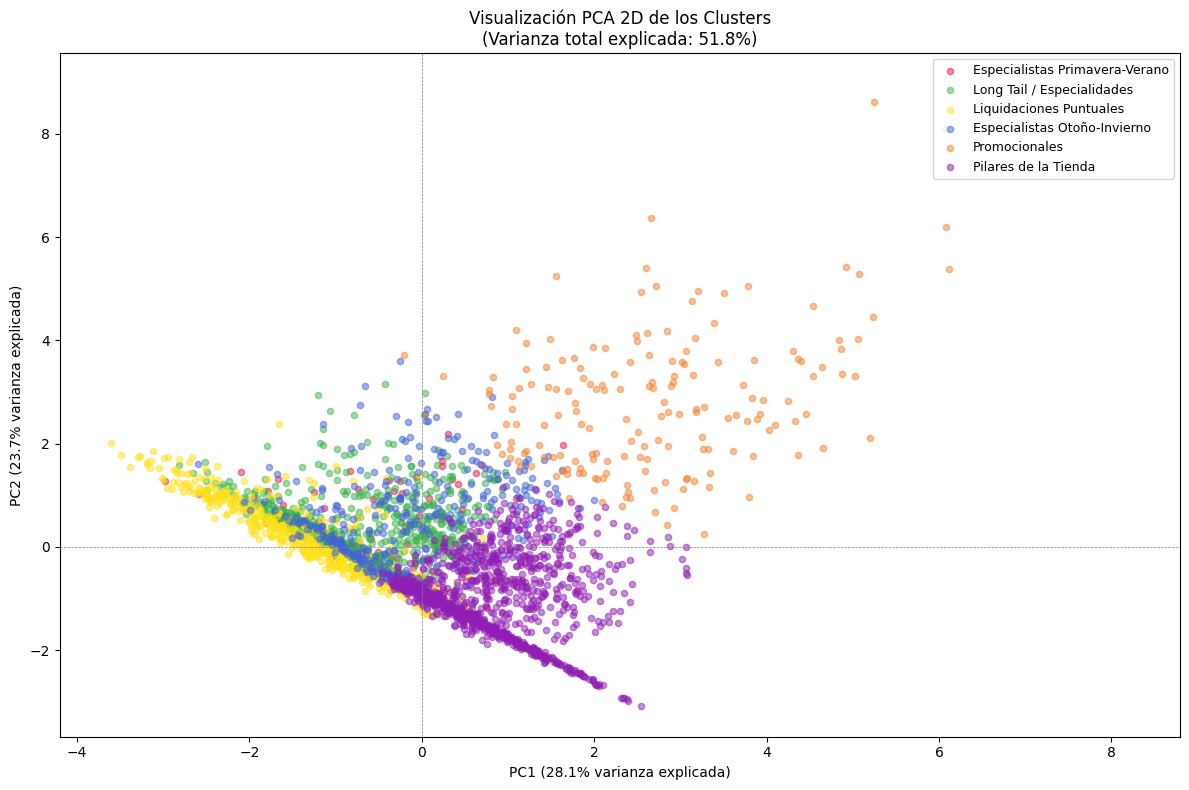


Varianza explicada por PC1: 28.1%
Varianza explicada por PC2: 23.7%
Varianza total capturada:   51.8%


In [ ]:

# PCA sobre los datos escalados
pca = PCA(n_components=2)
coords = pca.fit_transform(X_procesado)
coords = np.array(coords)  # ← añadir esta línea

varianza_pc1 = pca.explained_variance_ratio_[0] * 100
varianza_pc2 = pca.explained_variance_ratio_[1] * 100
varianza_total = varianza_pc1 + varianza_pc2

colores = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4']
nombres = {
    0: "Especialistas Primavera-Verano",
    1: "Long Tail / Especialidades",
    2: "Liquidaciones Puntuales",
    3: "Especialistas Otoño-Invierno",
    4: "Promocionales",
    5: "Pilares de la Tienda"
}

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id, nombre in nombres.items():
    mask = labels == cluster_id
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=colores[cluster_id], label=nombre,
        alpha=0.5, s=20
    )

ax.set_xlabel(f'PC1 ({varianza_pc1:.1f}% varianza explicada)')
ax.set_ylabel(f'PC2 ({varianza_pc2:.1f}% varianza explicada)')
ax.set_title(f'Visualización PCA 2D de los Clusters\n(Varianza total explicada: {varianza_total:.1f}%)')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada por PC1: {varianza_pc1:.1f}%")
print(f"Varianza explicada por PC2: {varianza_pc2:.1f}%")
print(f"Varianza total capturada:   {varianza_total:.1f}%")

In [ ]:
columnas_originales = ['volumen_total', 'precio_medio', 'frecuencia_venta', 'volatilidad', 'p_oferta', 'profundidad_descuento', 'p_primavera_verano'] 



loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['Peso_en_PC1', 'Peso_en_PC2'], 
    index=columnas_originales
)


print("--- QUÉ SIGNIFICA EL EJE X (PC1) ---")
print(loadings.sort_values(by='Peso_en_PC1', ascending=False)['Peso_en_PC1'])
print("\n--- QUÉ SIGNIFICA EL EJE Y (PC2) ---")
print(loadings.sort_values(by='Peso_en_PC2', ascending=False)['Peso_en_PC2'])

--- QUÉ SIGNIFICA EL EJE X (PC1) ---
p_oferta                 0.636653
volumen_total            0.405431
frecuencia_venta         0.350383
p_primavera_verano       0.015884
precio_medio            -0.211330
volatilidad             -0.360151
profundidad_descuento   -0.364567
Name: Peso_en_PC1, dtype: float64

--- QUÉ SIGNIFICA EL EJE Y (PC2) ---
p_oferta                 0.763006
volatilidad              0.378112
profundidad_descuento    0.198705
precio_medio             0.148908
p_primavera_verano      -0.025239
volumen_total           -0.310299
frecuencia_venta        -0.340989
Name: Peso_en_PC2, dtype: float64


La proyección captura el 51.7% de la varianza total.
Los clusters Especialistas Primavera-Verano y Otoño-Invierno 
presentan mayor separación en el espacio original de 7 dimensiones,
especialmente a través de la variable p_primavera_verano,
que no está completamente representada en estas 2 componentes.

### Visualización PCA 3D

Añadiendo una tercera componente principal capturamos varianza adicional y obtenemos una visión más completa de la separación entre clusters en el espacio reducido.

In [ ]:

# 1. Calculamos el PCA, pidiendo 3 dimensiones
pca_3d = PCA(n_components=3)
coords_3d = pca_3d.fit_transform(X_procesado)


coords_3d = np.array(coords_3d) 


var_pc1 = pca_3d.explained_variance_ratio_[0] * 100
var_pc2 = pca_3d.explained_variance_ratio_[1] * 100
var_pc3 = pca_3d.explained_variance_ratio_[2] * 100
var_total_3d = var_pc1 + var_pc2 + var_pc3


nombres = {
    0: "Especialistas Primavera-Verano",
    1: "Long Tail / Especialidades",
    2: "Liquidaciones Puntuales",
    3: "Especialistas Otoño-Invierno",
    4: "Promocionales",
    5: "Pilares de la Tienda"
}


df_pca_3d = pd.DataFrame({
    'PC1': coords_3d[:, 0], 
    'PC2': coords_3d[:, 1],
    'PC3': coords_3d[:, 2],
    'Cluster_ID': labels 
})
df_pca_3d['Nombre_Cluster'] = df_pca_3d['Cluster_ID'].map(nombres)


fig = px.scatter_3d(
    df_pca_3d, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Nombre_Cluster',
    opacity=0.2,
    title=f'Visualización PCA 3D (Varianza total: {var_total_3d:.1f}%)',
    labels={
        'PC1': f'PC1 ({var_pc1:.1f}%)',
        'PC2': f'PC2 ({var_pc2:.1f}%)',
        'PC3': f'PC3 ({var_pc3:.1f}%)'
    }
)


fig.update_traces(marker=dict(size=4))


fig.show()

print(f"\nVarianza extra capturada por el PC3: {var_pc3:.1f}%")
print(f"Varianza total acumulada: {var_total_3d:.1f}%")


Varianza extra capturada por el PC3: 21.5%
Varianza total acumulada: 73.3%


## 8. Exportación para Power BI

Exportamos el dataset enriquecido con la asignación de cluster y el nombre de segmento para su integración en el dashboard de Power BI del proyecto DSMarket.

El fichero `datos_productos_powerbi.csv` contiene las 7 features en escala original (sin normalizar) junto con el número y nombre de cluster asignado, listo para cargar directamente en Power BI.

In [ ]:

mapeo_nombres = {
    0: "Especialistas Primavera-Verano",
    1: "Long Tail / Especialidades",
    2: "Liquidaciones Puntuales",
    3: "Especialistas Otoño-Invierno",
    4: "Promocionales",
    5: "Pilares de la Tienda"
}
df_cluster_display['Nombre_Cluster'] = df_cluster['cluster'].map(mapeo_nombres)


df_cluster_display.to_csv('datos_productos_powerbi.csv')